In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
# IMPORTANTE: utilizar header=None
df_original = pd.read_csv(
    "Analisis GAC Full7agosto 2026(CPL FACEBOOK).csv",
    header=None,
    encoding="utf-8-sig",
    dtype=str,
    keep_default_na=False
)

# Comprobar las primeras filas
df_original.head(5)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,,"Abril, 25","Mayo, 25","Junio, 25","Julio, 25","Agosto, 25","Septiembre, 25","Octubre, 25","Noviembre, 25","Diciembre, 25","Enero, 26","Febrero, 26",Mar-26,Apr-26,
1,CAMPAÑAS,12,12,15,14,13,11,13,11,10,11,10,12,10,
2,LEADS,256,230,387,288,260,245,280,211,283,350,338,308,422,
3,PRESUPUESTO,"$29,737.00","$41,463.00","$58,316.00","$41,073.00","$43,532.00","$64,541.00","$50,506.00","$69,000.00","$98,900.00","$118,000.00","93,734.39","$82,979.38",110381.53,
4,COSTO POR LEAD,$116.16,$180.27,$150.69,$142.61,$167.43,$263.43,$180.38,$327.01,$349.47,$337.14,$304.33,$269.41,$261.56,$234.61


In [23]:
# Revisar la estructura original
print("Dimensiones originales:", df_original.shape)

df_original.head(10)

Dimensiones originales: (21, 15)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,,"Abril, 25","Mayo, 25","Junio, 25","Julio, 25","Agosto, 25","Septiembre, 25","Octubre, 25","Noviembre, 25","Diciembre, 25","Enero, 26","Febrero, 26",Mar-26,Apr-26,
1,CAMPAÑAS,12,12,15,14,13,11,13,11,10,11,10,12,10,
2,LEADS,256,230,387,288,260,245,280,211,283,350,338,308,422,
3,PRESUPUESTO,"$29,737.00","$41,463.00","$58,316.00","$41,073.00","$43,532.00","$64,541.00","$50,506.00","$69,000.00","$98,900.00","$118,000.00","93,734.39","$82,979.38",110381.53,
4,COSTO POR LEAD,$116.16,$180.27,$150.69,$142.61,$167.43,$263.43,$180.38,$327.01,$349.47,$337.14,$304.33,$269.41,$261.56,$234.61
5,,,,,,,,,,,,,,,
6,,,,,,,,,,,,,,,
7,,,,,,,,,,,,,,,
8,MES,ENERO,FEBRERO,MARZO,ABRIL,MAYO,,,,,,,,,
9,LEADS FACEBOOK,417,346,359,456,386,,,,,,,,,


In [24]:
# Seleccionar la primera tabla
df = df_original.iloc[0:5, 0:14].copy()

# Transponer utilizando la primera columna como índice
df = df.set_index(df.columns[0]).T

# Reiniciar el índice
df.reset_index(drop=True, inplace=True)

# Asignar nombres
df.columns = [
    "Mes",
    "Campanas",
    "Leads",
    "Presupuesto",
    "Costo_por_Lead"
]

# Revisar antes de convertir los datos
df

,Mes,Campanas,Leads,Presupuesto,Costo_por_Lead
0,"Abril, 25",12,256,"$29,737.00",$116.16
1,"Mayo, 25",12,230,"$41,463.00",$180.27
2,"Junio, 25",15,387,"$58,316.00",$150.69
3,"Julio, 25",14,288,"$41,073.00",$142.61
4,"Agosto, 25",13,260,"$43,532.00",$167.43
5,"Septiembre, 25",11,245,"$64,541.00",$263.43
6,"Octubre, 25",13,280,"$50,506.00",$180.38
7,"Noviembre, 25",11,211,"$69,000.00",$327.01
8,"Diciembre, 25",10,283,"$98,900.00",$349.47
9,"Enero, 26",11,350,"$118,000.00",$337.14


In [25]:
# Limpiar las columnas monetarias sin eliminar sus valores
for columna in ["Presupuesto", "Costo_por_Lead"]:

    df[columna] = (
        df[columna]
        .astype(str)
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.strip()
    )

    df[columna] = pd.to_numeric(
        df[columna],
        errors="coerce"
    )

In [26]:
for columna in ["Campanas", "Leads"]:

    df[columna] = pd.to_numeric(
        df[columna],
        errors="coerce"
    )

In [27]:
df[
    ["Mes", "Presupuesto", "Leads", "Costo_por_Lead"]
]

,Mes,Presupuesto,Leads,Costo_por_Lead
0,"Abril, 25",29737.00,256,116.16
1,"Mayo, 25",41463.00,230,180.27
2,"Junio, 25",58316.00,387,150.69
3,"Julio, 25",41073.00,288,142.61
4,"Agosto, 25",43532.00,260,167.43
5,"Septiembre, 25",64541.00,245,263.43
6,"Octubre, 25",50506.00,280,180.38
7,"Noviembre, 25",69000.00,211,327.01
8,"Diciembre, 25",98900.00,283,349.47
9,"Enero, 26",118000.00,350,337.14


In [28]:
df[
    ["Mes", "Presupuesto", "Leads", "Costo_por_Lead"]
]

,Mes,Presupuesto,Leads,Costo_por_Lead
0,"Abril, 25",29737.00,256,116.16
1,"Mayo, 25",41463.00,230,180.27
2,"Junio, 25",58316.00,387,150.69
3,"Julio, 25",41073.00,288,142.61
4,"Agosto, 25",43532.00,260,167.43
5,"Septiembre, 25",64541.00,245,263.43
6,"Octubre, 25",50506.00,280,180.38
7,"Noviembre, 25",69000.00,211,327.01
8,"Diciembre, 25",98900.00,283,349.47
9,"Enero, 26",118000.00,350,337.14


In [ ]:
#Confirmar que no hay valores nulos en la columna "Costo_por_Lead"
print(df["Costo_por_Lead"].isna().sum())
print(df["Costo_por_Lead"].tolist())

0
[116.16, 180.27, 150.69, 142.61, 167.43, 263.43, 180.38, 327.01, 349.47, 337.14, 304.33, 269.41, 261.56]


In [31]:
# Limpiar espacios y caracteres invisibles en la columna Mes
df["Mes"] = (
    df["Mes"]
    .astype(str)
    .str.replace("\u00a0", "", regex=False)
    .str.strip()
)

# Reemplazar textos vacíos por valores nulos
df["Mes"] = df["Mes"].replace(
    ["", " ", "nan", "None"],
    np.nan
)

In [32]:
# Crear fechas mensuales en orden cronológico
df["Fecha"] = pd.date_range(
    start="2025-04-01",
    periods=len(df),
    freq="MS"
)

# Crear columnas adicionales de año y mes
df["Anio"] = df["Fecha"].dt.year
df["Numero_Mes"] = df["Fecha"].dt.month

In [33]:
# Establecer el orden de las columnas
orden_columnas = [
    "Fecha",
    "Mes",
    "Anio",
    "Numero_Mes",
    "Campanas",
    "Leads",
    "Presupuesto",
    "Costo_por_Lead"
]

df = df[orden_columnas]

df.head()

,Fecha,Mes,Anio,Numero_Mes,Campanas,Leads,Presupuesto,Costo_por_Lead
0,2025-04-01,"Abril, 25",2025,4,12,256,29737.0,116.16
1,2025-05-01,"Mayo, 25",2025,5,12,230,41463.0,180.27
2,2025-06-01,"Junio, 25",2025,6,15,387,58316.0,150.69
3,2025-07-01,"Julio, 25",2025,7,14,288,41073.0,142.61
4,2025-08-01,"Agosto, 25",2025,8,13,260,43532.0,167.43


In [34]:
print(df.dtypes)

Fecha             datetime64[us]
Mes                          str
Anio                       int32
Numero_Mes                 int32
Campanas                   int64
Leads                      int64
Presupuesto              float64
Costo_por_Lead           float64
dtype: object


In [35]:
#valores nulos
print("Valores faltantes por columna:")

print(df.isna().sum())

Valores faltantes por columna:
Fecha             0
Mes               0
Anio              0
Numero_Mes        0
Campanas          0
Leads             0
Presupuesto       0
Costo_por_Lead    0
dtype: int64


In [36]:
#Revisar y eliminar duplicados
print("Número de filas duplicadas:")
print(df.duplicated().sum())

Número de filas duplicadas:
0


In [37]:
# Eliminar únicamente filas completamente duplicadas
df.drop_duplicates(inplace=True)

# Reiniciar el índice
df.reset_index(drop=True, inplace=True)

In [38]:
#Revisar valores imposibles
columnas_validar = [
    "Campanas",
    "Leads",
    "Presupuesto",
    "Costo_por_Lead"
]

for columna in columnas_validar:

    cantidad_negativos = (df[columna] < 0).sum()

    print(
        columna,
        "- valores negativos:",
        cantidad_negativos
    )

Campanas - valores negativos: 0
Leads - valores negativos: 0
Presupuesto - valores negativos: 0
Costo_por_Lead - valores negativos: 0


In [39]:
# Calcular el costo por lead para comprobar los datos originales
df["Costo_por_Lead_Calculado"] = (
    df["Presupuesto"] / df["Leads"]
).round(2)

# Comparar el valor original con el calculado
df[
    [
        "Mes",
        "Presupuesto",
        "Leads",
        "Costo_por_Lead",
        "Costo_por_Lead_Calculado"
    ]
]

,Mes,Presupuesto,Leads,Costo_por_Lead,Costo_por_Lead_Calculado
0,"Abril, 25",29737.00,256,116.16,116.16
1,"Mayo, 25",41463.00,230,180.27,180.27
2,"Junio, 25",58316.00,387,150.69,150.69
3,"Julio, 25",41073.00,288,142.61,142.61
4,"Agosto, 25",43532.00,260,167.43,167.43
5,"Septiembre, 25",64541.00,245,263.43,263.43
6,"Octubre, 25",50506.00,280,180.38,180.38
7,"Noviembre, 25",69000.00,211,327.01,327.01
8,"Diciembre, 25",98900.00,283,349.47,349.47
9,"Enero, 26",118000.00,350,337.14,337.14


In [40]:
df["Diferencia_CPL"] = (
    df["Costo_por_Lead"]
    - df["Costo_por_Lead_Calculado"]
).abs().round(2)

df[
    [
        "Mes",
        "Costo_por_Lead",
        "Costo_por_Lead_Calculado",
        "Diferencia_CPL"
    ]
]

,Mes,Costo_por_Lead,Costo_por_Lead_Calculado,Diferencia_CPL
0,"Abril, 25",116.16,116.16,0.00
1,"Mayo, 25",180.27,180.27,0.00
2,"Junio, 25",150.69,150.69,0.00
3,"Julio, 25",142.61,142.61,0.00
4,"Agosto, 25",167.43,167.43,0.00
5,"Septiembre, 25",263.43,263.43,0.00
6,"Octubre, 25",180.38,180.38,0.00
7,"Noviembre, 25",327.01,327.01,0.00
8,"Diciembre, 25",349.47,349.47,0.00
9,"Enero, 26",337.14,337.14,0.00


In [41]:
print("Dimensiones de la base limpia:", df.shape)

df.info()

Dimensiones de la base limpia: (13, 10)
<class 'pandas.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Fecha                     13 non-null     datetime64[us]
 1   Mes                       13 non-null     str           
 2   Anio                      13 non-null     int32         
 3   Numero_Mes                13 non-null     int32         
 4   Campanas                  13 non-null     int64         
 5   Leads                     13 non-null     int64         
 6   Presupuesto               13 non-null     float64       
 7   Costo_por_Lead            13 non-null     float64       
 8   Costo_por_Lead_Calculado  13 non-null     float64       
 9   Diferencia_CPL            13 non-null     float64       
dtypes: datetime64[us](1), float64(4), int32(2), int64(2), str(1)
memory usage: 1.0 KB


Regresión lineal

¿En qué medida el presupuesto mensual invertido en campañas de Facebook se relaciona con la cantidad de leads obtenidos?

Variable independiente X: Presupuesto
Variable dependiente Y: Leads

In [42]:
#Crear el df para la regresion lineal
# Seleccionar solamente las dos variables de la regresión
df_regresion = df[
    ["Presupuesto", "Leads"]
].copy()

# Eliminar únicamente filas incompletas en estas dos variables
df_regresion.dropna(inplace=True)

# Reiniciar el índice
df_regresion.reset_index(drop=True, inplace=True)

df_regresion

,Presupuesto,Leads
0,29737.00,256
1,41463.00,230
2,58316.00,387
3,41073.00,288
4,43532.00,260
5,64541.00,245
6,50506.00,280
7,69000.00,211
8,98900.00,283
9,118000.00,350


In [43]:
# Variable independiente X
Vars_Indep = df_regresion[["Presupuesto"]]

# Variable dependiente Y
Var_Dep = df_regresion["Leads"]

In [44]:
print("Dimensiones de X:", Vars_Indep.shape)
print("Dimensiones de Y:", Var_Dep.shape)

Dimensiones de X: (13, 1)
Dimensiones de Y: (13,)


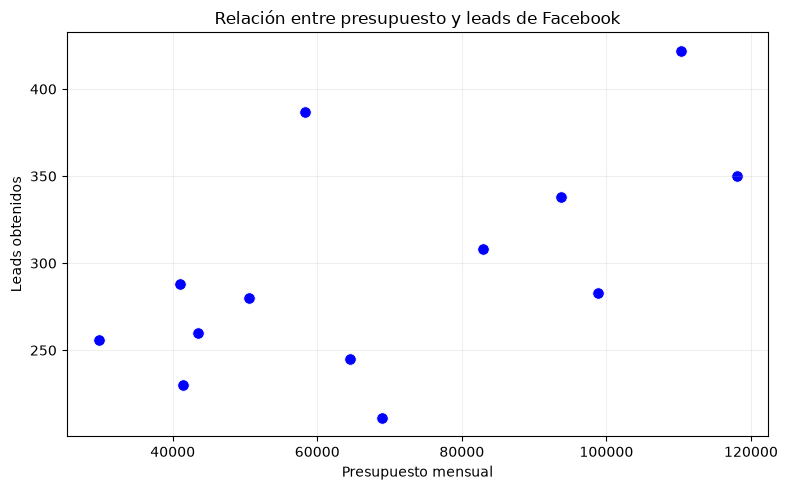

In [45]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_regresion,
    x="Presupuesto",
    y="Leads",
    color="blue",
    s=70
)

plt.title("Relación entre presupuesto y leads de Facebook")
plt.xlabel("Presupuesto mensual")
plt.ylabel("Leads obtenidos")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

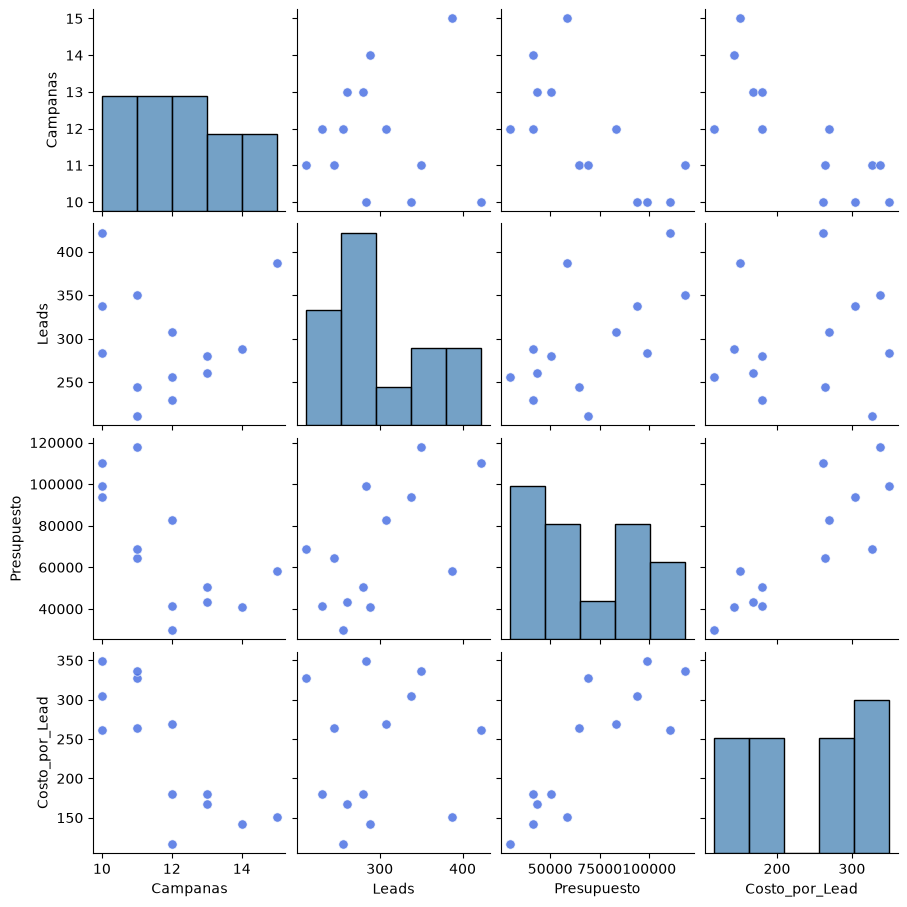

In [46]:
variables_grafica = [
    "Campanas",
    "Leads",
    "Presupuesto",
    "Costo_por_Lead"
]

df_pairplot = df[variables_grafica].copy()

sns.pairplot(
    df_pairplot,
    diag_kind="hist",
    height=2.3,
    plot_kws={
        "color": "royalblue",
        "s": 45,
        "alpha": 0.8
    },
    diag_kws={
        "color": "steelblue",
        "edgecolor": "black"
    }
)

plt.show()

In [47]:
# Calcular las correlaciones entre las variables numéricas seleccionadas
Corr_Factors = df_pairplot.corr()

Corr_Factors

,Campanas,Leads,Presupuesto,Costo_por_Lead
Campanas,1.000000,-0.018257,-0.674121,-0.782088
Leads,-0.018257,1.000000,0.590660,0.101252
Presupuesto,-0.674121,0.590660,1.000000,0.848175
Costo_por_Lead,-0.782088,0.101252,0.848175,1.000000


In [48]:
Corr_Factors1 = abs(Corr_Factors)

Corr_Factors1

,Campanas,Leads,Presupuesto,Costo_por_Lead
Campanas,1.000000,0.018257,0.674121,0.782088
Leads,0.018257,1.000000,0.590660,0.101252
Presupuesto,0.674121,0.590660,1.000000,0.848175
Costo_por_Lead,0.782088,0.101252,0.848175,1.000000


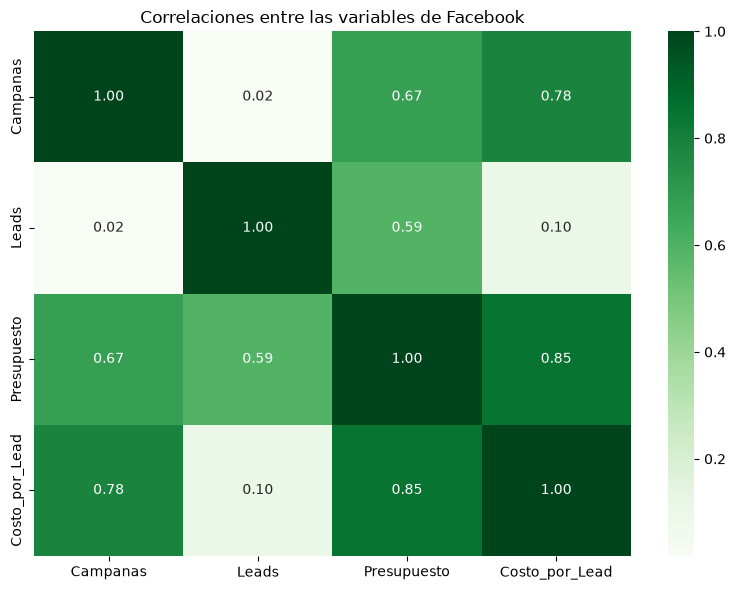

In [49]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    Corr_Factors1,
    cmap="Greens",
    annot=True,
    fmt=".2f"
)

plt.title("Correlaciones entre las variables de Facebook")
plt.tight_layout()
plt.show()